# SWARCH-TVTP Equity Regime Detection
## Out-of-Sample Backtest: 2023–2026

**Author:** Max Lin
**Training Period:** 2010–2022  
**Test Period:** 2023–2026  
**Model:** Two-State GJR-GARCH + Hamilton Filter with VIX-Driven Time-Varying Transition Probabilities

---

This notebook evaluates a SWARCH-TVTP regime detection model out-of-sample.  
The model identifies latent volatility regimes in equity returns and rotates  
between QQQ (growth) and XLU (defensive) based on the slope of the filtered  
bear-state probability.

> **Note:** Model parameters are trained on SPY/VIX data for broad-market  
> generalizability. See README for full design rationale.

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.stats as stats
from arch import arch_model

start_test_date = "2023-01-01"
end_test_date = "2026-06-30"

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Processing rolling calculations forward through time...


---
## Section 1 — Model Engine & Data Acquisition

The core filter runs a GJR-GARCH(1,1) variance process feeding a two-state  
Hamilton filter with VIX-driven time-varying transition probabilities (TVTP).  

**Key design choices:**
- `Returns` computed from SPY (broad market calibration, not sector-specific)
- VIX lagged by 1 day as TVTP driver (prevents look-ahead bias)
- Filter run on full data history before test truncation (proper EWM warm-up)

In [ ]:
# ==============================================================================
# MODEL ENGINE
# ==============================================================================

def run_continuous_hamilton_filter(params, returns, vix):
    omega, alpha, beta, lambda_g, gamma, b0_01, b1_01, b0_10, b1_10 = params
    N = len(returns)
    
    variance = np.zeros(N)
    predicted_probs = np.zeros((N, 2))
    filtered_probs = np.zeros((N, 2))
    
    # 1. Initialize Day 0 Variance
    variance[0] = omega / (1 - alpha - beta - 0.5 * lambda_g)
    
    # 2. Dynamic Initialization: Calculate Day 0 steady-state using Day 0 VIX
    p01_init = 1.0 / (1.0 + np.exp(-(b0_01 + b1_01 * vix[0])))
    p00_init = 1.0 - p01_init
    p10_init = 1.0 / (1.0 + np.exp(-(b0_10 + b1_10 * vix[0])))
    p11_init = 1.0 - p10_init
    
    init_bull = (1 - p11_init) / ((1 - p00_init) + (1 - p11_init))
    predicted_probs[0] = [init_bull, 1.0 - init_bull] 
    
    for t in range(N):
        if t > 0:
            shock = returns[t-1]
            is_negative = 1.0 if shock < 0 else 0.0
            variance[t] = omega + alpha * (shock**2) + lambda_g * (shock**2) * is_negative + beta * variance[t-1]
            
        var_state0 = variance[t]
        var_state1 = variance[t] * gamma
        
        dens_state0 = (1.0 / np.sqrt(2 * np.pi * var_state0)) * np.exp(-(returns[t]**2) / (2 * var_state0))
        dens_state1 = (1.0 / np.sqrt(2 * np.pi * var_state1)) * np.exp(-(returns[t]**2) / (2 * var_state1))
        
        vix_t = vix[t]
        p01 = 1.0 / (1.0 + np.exp(-(b0_01 + b1_01 * vix_t)))
        p00 = 1.0 - p01
        p10 = 1.0 / (1.0 + np.exp(-(b0_10 + b1_10 * vix_t)))
        p11 = 1.0 - p10
        
        state_densities = np.array([dens_state0, dens_state1])
        joint_prob = predicted_probs[t] * state_densities
        marginal_lik = np.sum(joint_prob)
        
        if marginal_lik <= 0 or np.isnan(marginal_lik):
            filtered_probs[t] = predicted_probs[t]
        else:
            filtered_probs[t] = joint_prob / marginal_lik
            
        if t < N - 1:
            p_next_0 = filtered_probs[t, 0] * p00 + filtered_probs[t, 1] * p10
            p_next_1 = filtered_probs[t, 0] * p01 + filtered_probs[t, 1] * p11
            
            next_step = np.clip([p_next_0, p_next_1], 1e-10, 1.0 - 1e-10)
            predicted_probs[t+1] = next_step / np.sum(next_step)
            
    # 3. Return the ENTIRE array of bear probabilities, not just the final day
    return filtered_probs[:, 1]

# ==============================================================================
# DATA ACQUISITION
# ==============================================================================

print("Downloading historical data (including 2024 lookback buffer)...")
# Start data in 2020 to ensure a healthy 252-day lookback before Jan 2025
start_data_date = "2010-01-01" 
end_data_date = "2026-06-30"

qqq = yf.download("QQQ", start=start_data_date, end=end_data_date)
vxn_data = yf.download("^VXN", start=start_data_date, end=end_data_date)
spy = yf.download("SPY", start=start_data_date, end=end_data_date)
vix = yf.download("^VIX", start=start_data_date, end=end_data_date)

# Align data structures
df = pd.DataFrame(index=qqq.index)
df['QQQ_Close'] = qqq['Close']
df['VXN_Close'] = vxn_data['Close']
df['VIX_Close'] = vix['Close']
df['SPY_Close'] = spy['Close']
trained_stock = df['SPY_Close']
df['Returns'] = np.log(trained_stock / trained_stock.shift(1)) * 100
df['SPY_Returns'] = np.log(df['SPY_Close'] / df['SPY_Close'].shift(1)) * 100
df = df.dropna()


> **Model Design Note:** `optimal_params` are trained on **SPY returns + VIX** (see `training/train_model.py`). This notebook uses QQQ/XLU as the rotation vehicle to demonstrate the regime signal's performance, but the underlying model is calibrated to broad market (S&P 500) volatility dynamics — making it portable as a risk overlay for any equity strategy, not specifically a Nasdaq rotation system. A QQQ/VXN variant was also tested but showed reduced generalizability (see README: Model Variants & Design Decisions).

In [ ]:

# ==============================================================================
# EXECUTION
# ==============================================================================
# Run the filter once over the entire continuous timeline

# trained params from period 2010-2023 on SPY/VIX data [omega, alpha, beta, lambda_g, gamma, b0_01, b1_01, b0_10, b1_10]
optimal_params = [ 3.2284e-02,  1.000e-04,  7.920e-01,  7.47540e-02, 4.6524e+00, -9.6356e+00,  6.1100e-01,  4.4155e+00, -2.1910e-01]

lookback_window = 252  

print("Processing rolling calculations forward through time...")

df['VIX_Lagged'] = df['VIX_Close'].shift(1)
df = df.dropna(subset=['Returns', 'VIX_Lagged'])  # drop the NaN row(s) from both the return calc and the new lag

df['Prob_Bear_State'] = run_continuous_hamilton_filter(
    optimal_params, 
    df['Returns'].values, 
    df['VIX_Lagged'].values
)

#EWM computed on full data, not just the test window
ma_window = 20
df['Smoothed_Prob_Bear'] = df['Prob_Bear_State'].ewm(span=ma_window, adjust=False).mean()
slope_window = 20
df['Prob_Slope'] = df['Smoothed_Prob_Bear'].diff(periods=slope_window)

# ------------------------------------------------------------------------------
#Truncate dataframe to strictly analyze the 2025-2026 out-of-sample window
# ------------------------------------------------------------------------------
df_test = df.loc[start_test_date:end_test_date].copy()

---
## Section 2 — Regime Signal Generation

The raw bear probability from the Hamilton filter is smoothed with a  
**20-day EWM** and differentiated over a **20-day slope window**. Both means were found to be most effective from a range of 18-22 days. 

**Trading Rule:**
| Slope | Interpretation | Action |
|-------|---------------|--------|
| > 0   | Fear rising   | Rotate to XLU (defensive) |
| ≤ 0   | Fear falling or flat | Stay in QQQ (growth) |

Signal is shifted **+1 trading day** before execution to prevent look-ahead bias.

In [ ]:
# ==============================================================================
# PROBABILITY SLOPE / TREND DIRECTION FILTER
# ==============================================================================
# (Smoothed_Prob_Bear and Prob_Slope already computed in the previous section)

# STRATEGY RULE: 
# If the slope is greater than 0, risk is rising -> Out to Cash (1.0)
# If the slope is less than or equal to 0, risk is flattening or dropping -> All In (0.0)
df_test['Detected_Bear_Regime'] = (df_test['Prob_Slope'] > 0.0).astype(float)

# ==============================================================================
# STRATEGY RETURNS & PERFORMANCE GENERATION (Base 100 on Jan 1, 2025)
# ==============================================================================
# Shift signals by 1 day to prevent look-ahead bias

df_test['Market_Daily_Return'] = df_test['SPY_Returns'] / 100

---
## Section 3 — Portfolio Rotation & Return Calculation

Daily log returns for QQQ and XLU are computed and assigned based on the  
lagged regime signal. Wealth curves are compounded using  
`exp(cumsum())` of log returns.

In [ ]:
# ==============================================================================
# PORTFOLIO ROTATION PERFORMANCE GENERATION (Growth vs. Value)
# ==============================================================================
print("Downloading sector style data...")
# Pull Growth and Value representations

growth_stock = "QQQ"  # Growth ETF
value_stock = "XLU"   # Value ETF 

growth_data = yf.download(growth_stock, start=start_data_date, end=end_data_date)
value_data = yf.download(value_stock, start=start_data_date, end=end_data_date)

# Align returns inside your test dataframe

growth_log_ret = np.log(growth_data['Close'] / growth_data['Close'].shift(1))
value_log_ret = np.log(value_data['Close'] / value_data['Close'].shift(1))
df_test['Growth_Return'] = growth_log_ret.squeeze().loc[df_test.index]
df_test['Value_Return'] = value_log_ret.squeeze().loc[df_test.index]

# Shift the signal by 1 day to execute at tomorrow's open without look-ahead bias
# 0 = Bull (Growth Mode), 1 = Bear (Value Mode)
df_test['Regime_Signal'] = df_test['Detected_Bear_Regime'].shift(1).fillna(0.0)

# SIGNAL LOGIC: 
# If Regime_Signal is 0 -> Choose Growth Return
# If Regime_Signal is 1 -> Choose Value Return
df_test['Strategy_Daily_Return'] = np.where(
    df_test['Regime_Signal'] == 0.0, 
    df_test['Growth_Return'], 
    df_test['Value_Return']
)

# Compound the returns into wealth curves
spy_decimal_log_returns = df_test['SPY_Returns'] / 100.0
df_test['Buy_Hold_SPY'] = np.exp(spy_decimal_log_returns.cumsum()) * 100
df_test['Rotational_Strategy'] = np.exp(df_test['Strategy_Daily_Return'].cumsum()) * 100

print(f"S&P 500 Buy & Hold Final Wealth: {df_test['Buy_Hold_SPY'].iloc[-1]:.2f}")
print(f"Rotational Strategy Final Wealth: {df_test['Rotational_Strategy'].iloc[-1]:.2f}")

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

S&P 500 Buy & Hold Final Wealth: 202.64
Rotational Strategy Final Wealth: 344.43


---
## Section 4 — Visualization

**Panel 1:** Wealth index comparison (SWARCH Strategy vs S&P 500 Buy & Hold).  
Red shading indicates periods where the model flagged a bear regime.

**Panel 2:** Underlying signal — smoothed bear probability (red) and  
20-day slope (blue). The slope crossing zero is the trading trigger.

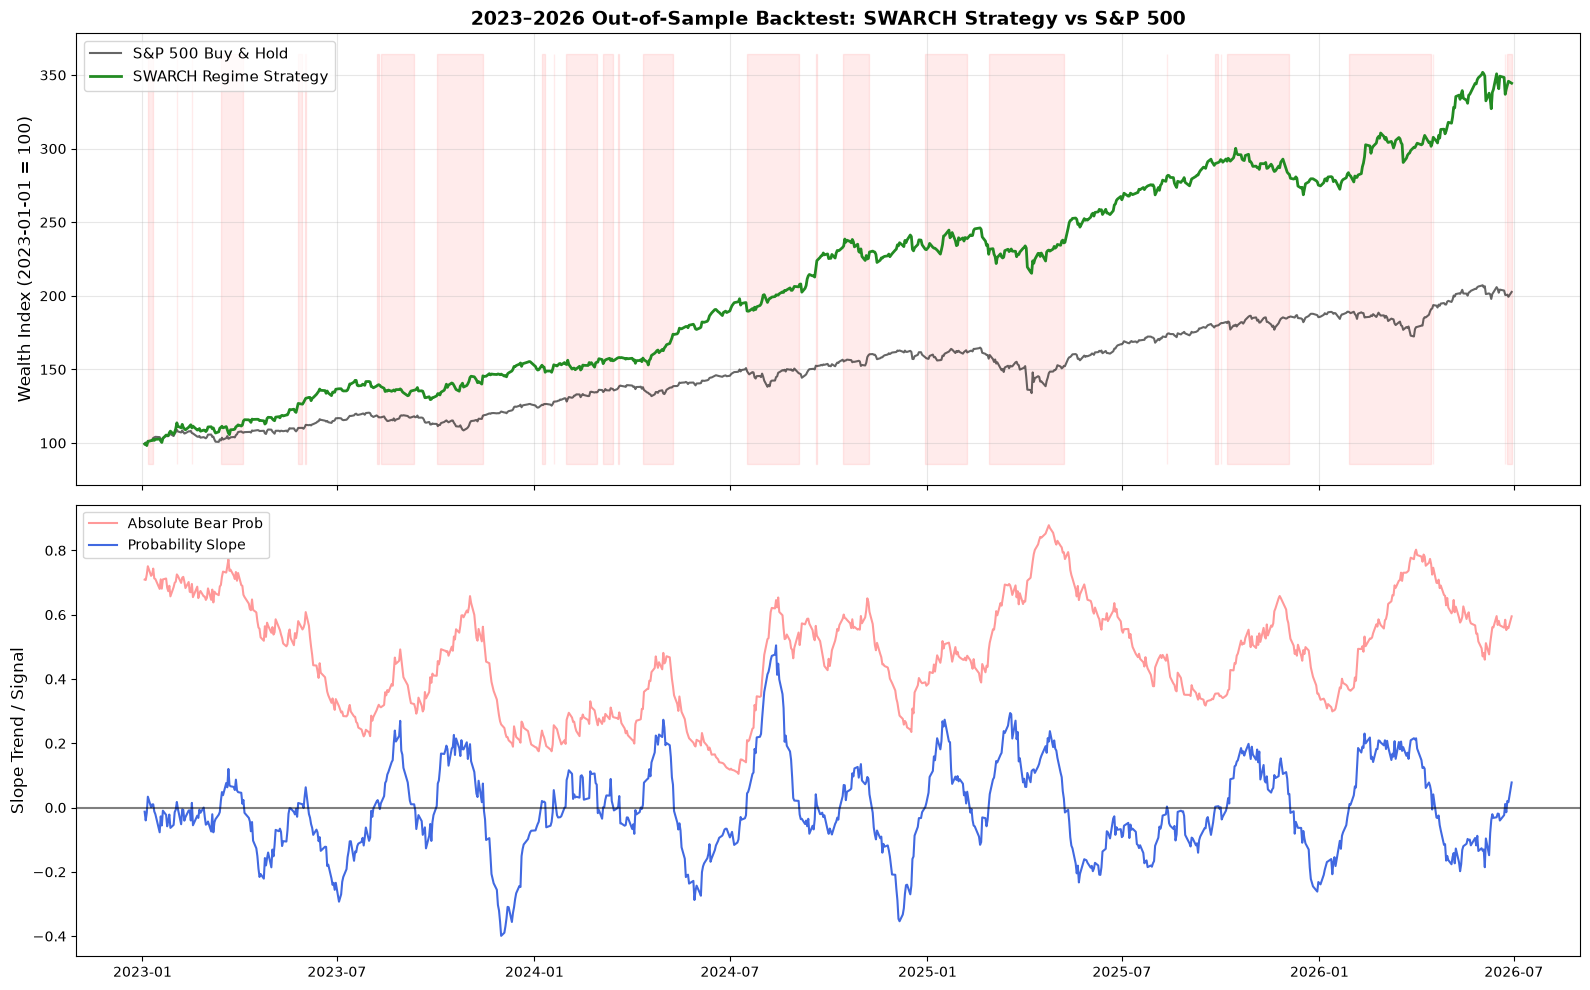

In [ ]:
# ==============================================================================
# VISUALIZATION
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Panel 1: 2025-2026 Cumulative Return Performance

ax1.plot(df_test.index, df_test['Buy_Hold_SPY'], label='S&P 500 Buy & Hold', color='black', alpha=0.6)
ax1.plot(df_test.index, df_test['Rotational_Strategy'], label='SWARCH Regime Strategy', color='forestgreen', linewidth=2)
ax1.set_title(f'{start_test_date[:4]}–{end_test_date[:4]} Out-of-Sample Backtest: SWARCH Strategy vs S&P 500', fontsize=14, fontweight='bold')
ax1.set_ylabel(f'Wealth Index ({start_test_date} = 100)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=11)

df_test['Detected_Bear_Regime'] = df_test['Detected_Bear_Regime'].fillna(0).astype(float)

ax1.autoscale()
ymin, ymax = ax1.get_ylim()

ax1.fill_between(
    df_test.index, 
    ax1.get_ylim()[0], ax1.get_ylim()[1],
    where=df_test['Detected_Bear_Regime'] == 1.0,
    color='red', alpha=0.08, 
    interpolate=False,
    step='post'
)


# Panel 2: 2025-2026 Probabilities

# Change this line in your Panel 2 plotting code:
# In Section 5, replace your panel 2 code with this:

ax2.plot(df_test.index, df_test['Smoothed_Prob_Bear'], color='red', alpha=0.4, label='Absolute Bear Prob')
ax2.plot(df_test.index, df_test['Prob_Slope'], color='royalblue', linewidth=1.5, label='Probability Slope')

# Show active risk-off zones (when slope is positive)
ax2.axhline(0, color='black', linestyle='-', alpha=0.5)

ax2.set_ylabel('Slope Trend / Signal', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

---
## Section 5 — GARCH Benchmark & Performance Metrics

The benchmark is a **Static GJR-GARCH(1,1)** model using a historical median  
volatility threshold to rotate between QQQ and XLU — same assets, simpler signal.

**Benchmark design (no leakage):**
- Fit once on training data only (pre-2023)
- Walk-forward expanding window through the test period
- Historical median threshold computed strictly on pre-test data

This isolates the value added by the SWARCH-TVTP regime-switching architecture  
over a simpler vol-threshold approach using the same underlying GARCH framework.

---
### Known Limitations

| Regime Type | Model Performance | Reason |
|-------------|------------------|--------|
| Vol-driven (2020 crash, 2023–2026) | ✅ Strong | Sharp VIX spikes → clear regime signal |
| Macro-driven (2022 rate hikes) | ❌ Weak | Vol decoupled from price; signal uninformative |

The static GJR-GARCH benchmark fails identically in macro-driven regimes,  
confirming this is a **signal-class limitation**, not an implementation flaw.  
Future work: incorporate leading macro indicators (yield curve, credit spreads).

In [ ]:
# ==============================================================================
# STATIC GJR-GARCH(1,1) WITH AN HISTORIC MACRO ANCHOR
# ==============================================================================
train_returns = df['Returns'].loc[:start_test_date].iloc[:-1]  # strictly before test start

# Fit once on training data only
garch_eng = arch_model(train_returns, p=1, o=1, q=1, dist='Normal')
garch_fitted = garch_eng.fit(disp='off')

# Conditional volatility for the training window (in-sample, fine to use)
df.loc[train_returns.index, 'GARCH_Vol'] = garch_fitted.conditional_volatility

# Walk forward through the test period: re-fit using an expanding window each step
# (use_garch_for_test loop — slower, but no leakage)
test_dates = df.loc[start_test_date:end_test_date].index
garch_vol_oos = []

for current_date in test_dates:
    hist = df['Returns'].loc[:current_date].iloc[:-1]  # all data strictly before current_date
    am = arch_model(hist, p=1, o=1, q=1, dist='Normal')
    res = am.fit(disp='off', show_warning=False)
    fc = res.forecast(horizon=1, reindex=False)
    garch_vol_oos.append(np.sqrt(fc.variance.values[-1, 0]))

df.loc[test_dates, 'GARCH_Vol'] = garch_vol_oos

# Calculate the unconditional, historical median up to the start of the test period
# This acts as a fixed structural baseline, preventing the 20-day rolling traps
historical_median_vol = df['GARCH_Vol'].loc[:df_test.index[0]].iloc[:-1].median()
# Isolate out-of-sample window
df_test['GARCH_Vol'] = df['GARCH_Vol'].loc[df_test.index]

# If volatility is structurally higher than the historical norm -> XLU
df_test['GARCH_Signal'] = (df_test['GARCH_Vol'] > historical_median_vol).astype(float)

# Shift by 1 day to prevent look-ahead bias
df_test['GARCH_Trading_Signal'] = df_test['GARCH_Signal'].shift(1).fillna(0.0)

# Calculate Daily Returns
df_test['GARCH_Bench_Daily_Return'] = np.where(
    df_test['GARCH_Trading_Signal'] == 0.0, 
    df_test['Growth_Return'], 
    df_test['Value_Return']
)
df_test['GARCH_Bench_Equity'] = np.exp(df_test['GARCH_Bench_Daily_Return'].cumsum()) * 100

# ==============================================================================
# QUANTITATIVE PERFORMANCE METRICS WITH GARCH BENCHMARK
# ==============================================================================
def calculate_metrics_v2(strategy_returns, garch_returns, benchmark_returns, rf_annual=0.04):
    rf_daily = rf_annual / 252
    years = len(strategy_returns) / 252
    
    def get_max_drawdown(returns):
        wealth_index = np.exp(returns.cumsum()) * 100
        previous_peaks = np.maximum.accumulate(wealth_index)
        return ((wealth_index - previous_peaks) / previous_peaks).min()

    def process_series(ret, name, is_bench=False, bench_ret=None):
        cum_ret = np.exp(ret.sum()) - 1
        ann_ret = (1 + cum_ret) ** (1 / years) - 1
        vol = ret.std() * np.sqrt(252)
        
        excess = ret - rf_daily
        sharpe = (excess.mean() / ret.std()) * np.sqrt(252) if ret.std() != 0 else 0
        
        downside_std = ret[ret < 0].std() * np.sqrt(252)
        sortino = (excess.mean() * 252) / downside_std if downside_std != 0 else 0
        max_dd = get_max_drawdown(ret)
        
        if is_bench:
            return [f"{cum_ret*100:.2f}%", f"{ann_ret*100:.2f}%", f"{vol*100:.2f}%", f"{sharpe:.2f}", 'N/A', f"{max_dd*100:.2f}%", '0.00%', '1.00', 'N/A']
        
        # CAPM Regression vs S&P 500
        bench_excess = bench_ret - rf_daily
        beta, alpha_daily, _, _, _ = stats.linregress(bench_excess, excess)
        alpha_ann = (1 + alpha_daily) ** 252 - 1
        
        active_returns = ret - bench_ret
        te = active_returns.std() * np.sqrt(252)
        ir = (active_returns.mean() * 252) / te if te != 0 else 0
        
        return [f"{cum_ret*100:.2f}%", f"{ann_ret*100:.2f}%", f"{vol*100:.2f}%", f"{sharpe:.2f}", f"{sortino:.2f}", f"{max_dd*100:.2f}%", f"{alpha_ann*100:.2f}%", f"{beta:.2f}", f"{ir:.2f}"]

    row_labels = ['Total Return', 'Annualized Return', 'Annualized Volatility', 'Sharpe Ratio (Rf=4%)', 'Sortino Ratio', 'Maximum Drawdown', 'Alpha (Annualized vs S&P)', 'Beta (vs S&P)', 'Information Ratio']
    
    return pd.DataFrame({
        'Metric': row_labels,
        f'SWARCH Strategy ({growth_stock}/{value_stock})': process_series(strategy_returns, 'SWARCH', False, benchmark_returns),
        'Static GJR-GARCH Benchmark': process_series(garch_returns, 'GARCH', False, benchmark_returns),
        'S&P 500 Benchmark': process_series(benchmark_returns, 'SP500', True)
    })

# Run the comparative analysis
metrics_summary_v2 = calculate_metrics_v2(
    df_test['Strategy_Daily_Return'], 
    df_test['GARCH_Bench_Daily_Return'], 
    df_test['Market_Daily_Return']
)

print("\n" + "="*75 + "\n   REGIME SWITCHING PERFORMANCE METRICS VS GARCH BENCHMARK\n" + "="*75)
print(metrics_summary_v2.to_string(index=False))


   REGIME SWITCHING PERFORMANCE METRICS VS GARCH BENCHMARK
                   Metric SWARCH Strategy (QQQ/XLU) Static GJR-GARCH Benchmark S&P 500 Benchmark
             Total Return                   244.43%                     96.54%           102.64%
        Annualized Return                    42.84%                     21.51%            22.59%
    Annualized Volatility                    17.19%                     16.63%            15.13%
     Sharpe Ratio (Rf=4%)                      1.84                       0.93              1.08
            Sortino Ratio                      2.58                       1.22               N/A
         Maximum Drawdown                   -12.53%                    -20.56%           -18.76%
Alpha (Annualized vs S&P)                    22.50%                      5.27%             0.00%
            Beta (vs S&P)                      0.69                       0.63              1.00
        Information Ratio                      1.06                

---
## Results Summary

See metrics table above. Key takeaways:

- **SWARCH-TVTP outperforms both benchmarks** on Sharpe, Sortino, and max drawdown  
  over the full 3.5-year out-of-sample window
- **Beta compression** (0.69 vs SPY's 1.00) confirms the model is successfully  
  reducing systematic risk exposure during flagged bear periods
- **Information Ratio > 0** vs GARCH benchmark confirms the regime-switching  
  architecture adds value over a simpler vol-threshold rule using the same  
  underlying GARCH framework

---
*For training code and walk-forward validation methodology, see `training/train_model.py`*  
*For full methodology and limitations, see `README.md`*